## Importing Packages

In [1]:
import os
import requests
import random
import time
from bs4 import BeautifulSoup
import shutil
import pandas as pd
import numpy as np
import seaborn as sns
import re
import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag

from string import punctuation
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from collections import defaultdict, Counter

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation, TruncatedSVD
import pyLDAvis
import pyLDAvis.lda_model
import pyLDAvis.gensim_models
from gensim.corpora import Dictionary
from gensim.models import LdaModel, CoherenceModel
from gensim.models.nmf import Nmf

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from keras.models import Sequential
from keras.layers import Dense
from sklearn.preprocessing import LabelBinarizer
from sklearn.metrics import roc_auc_score

import warnings
warnings.filterwarnings("ignore")

c:\Users\sowmi\AppData\Local\Programs\Python\Python310\lib\site-packages\tensorflow\__init__.py:30: DeprecationWarning: The distutils package is deprecated and slated for removal in Python 3.12. Use setuptools or check PEP 632 for potential alternatives
  import distutils as _distutils


In [2]:
# Function to find directory
def find_directory_path(target_dir, start_path='.') :
    
    for root, dirs, files in os.walk(start_path) :
        if target_dir in dirs :
            path = os.path.join(root, target_dir)
            
    return path

In [3]:
recipes_folder = "allrecipes"
recipes_folder_path = find_directory_path(recipes_folder)

In [4]:
# Dictionary to hold recipe contents
recipe_dictionary = {
    'Category': [],
    'SubCategory': [],
    'Title': [],
    'Description': [],
    'Ingredients': [],
    'Directions': [],
    'Prep Time': [],
    'Cook Time': [],
    'Total Time': [],
    'Servings': [],
    'Calories': [],
    'Fat': [],
    'Carbs': [],
    'Protein': []
}

# Iterate through each .txt file
recipes_folder = 'allrecipes/'
# Iterate through each .txt file
for recipe_file in os.listdir(recipes_folder):
    if recipe_file.endswith('.txt'):
        with open(os.path.join(recipes_folder, recipe_file), 'r', encoding='utf-8') as f:
            content = f.read()

        # Extract title, category, subcategory and sections
        category = content.split('\n')[0].replace('Category: ', '').strip()
        subcategory = content.split('\n')[1].replace('SubCategory: ', '').strip()
        title = content.split('\n')[3].replace('Title: ', '').strip()

        # Split the content into sections
        sections = content.split('\n\n')

        # Regex to capture servings line
        servings_pattern = re.compile(r'Original recipe \(1X\) yields (.+?) servings', re.IGNORECASE)
        
        # Initialize placeholders for values
        description = 'Not available'
        ingredients = []
        directions = []
        prep_time = 'No Prep Time'
        cook_time = 'No Cook Time'
        total_time = 'No Total Time'
        serving = 'No Servings'
        calories = 'Not available'
        fat = 'Not available'
        carbs = 'Not available'
        protein = 'Not available'
        
        # Flags for capturing ingredients and directions
        ingre_capturing = False
        direction_capturing = False

        # read sections
        for section in sections:
            section_lower = section.lower()

            # Detect and capture servings
            servings_match = servings_pattern.search(section)
            if servings_match:
                serving = f"{servings_match.group(1)} servings"
                ingre_capturing = True
                continue

            # Detect sections and update flags
            if 'Ingredients:' in section:
                ingre_capturing = True
                continue 
            elif 'Directions:' in section:
                ingre_capturing = False
                direction_capturing = True
                continue
            elif 'Description:' in section:
                description = section.split(':', 1)[1].strip() if ':' in section else 'Not available'
            elif 'prep time' in section_lower:
                direction_capturing = False
                prep_time = section.split(':', 1)[1].strip() if ':' in section else 'Not available'
            elif 'cook time' in section_lower:
                cook_time = section.split(':', 1)[1].strip() if ':' in section else 'Not available'
            elif 'total time' in section_lower:
                total_time = section.split(':', 1)[1].strip() if ':' in section else 'Not available'
            elif 'servings' in section_lower:
                serving = section.split(':', 1)[1].strip() if ':' in section else 'Not available'
            
            elif 'calories' in section_lower:
                calories = ''.join(filter(str.isdigit, section))
            elif 'fat' in section_lower:
                fat = section.split('\n')[1].strip() if len(section.split('\n')) > 1 else 'Not available'
            elif 'carbs' in section_lower:
                carbs = section.split('\n')[1].strip() if len(section.split('\n')) > 1 else 'Not available'
            elif 'protein' in section_lower:
                protein = ''.join(filter(str.isdigit, section))
                
            # Capture ingredients and directions
            elif ingre_capturing and section.strip():
                # Ignore any lines that look like "1x, 2x, 4x..." or error messages
                if re.match(r'^\d+x$', section.strip()) or 'oops' in section.lower():
                    continue
                ingredients.append(section.strip())
            elif direction_capturing and section.strip():
                directions.append(section.strip())
        
        # Finalize the cleaning
        cleaned_ingredients = [ingredient for ingredient in ingredients if not re.search(r'Original recipe \(1X\) yields', ingredient)]

        # Append to the dictionary
        recipe_dictionary['Category'].append(category)
        recipe_dictionary['SubCategory'].append(subcategory)
        recipe_dictionary['Title'].append(title)
        recipe_dictionary['Description'].append(description)
        recipe_dictionary['Ingredients'].append(', '.join(cleaned_ingredients))
        recipe_dictionary['Directions'].append(', '.join(directions))
        recipe_dictionary['Prep Time'].append(prep_time)
        recipe_dictionary['Cook Time'].append(cook_time)
        recipe_dictionary['Total Time'].append(total_time)
        recipe_dictionary['Servings'].append(serving)
        recipe_dictionary['Calories'].append(calories)
        recipe_dictionary['Fat'].append(fat)
        recipe_dictionary['Carbs'].append(carbs)
        recipe_dictionary['Protein'].append(protein)


In [53]:
recipes_df = pd.DataFrame(recipe_dictionary)
recipes_df.head()

,Category,SubCategory,Title,Description,Ingredients,Directions,Prep Time,Cook Time,Total Time,Servings,Calories,Fat,Carbs,Protein
0,dairy,cheese,10 Layer Dip,This 10 layer dip really has 10 distinct layer...,"1 (15 ounce) can refried beans, 12 ounce...",Spread beans into an even layer on the bottom ...,20 mins,No Cook Time,20 mins,Not available,227,Saturated Fat,10g,9
1,flours,corn-flour,1-Dish Taco Bake,Here's a one-dish family pleaser with all your...,"1 pound ground beef, 1 (1.25 ounce) pack...",Brown ground beef and drain. Add taco seasonin...,20 mins,30 mins,50 mins,Not available,534,Saturated Fat,42g,25
2,meat-and-poultry,chicken,3-Ingredient Baked BBQ Chicken Wings,This BBQ sauce is unexplainable. Its not a ric...,"5 pounds frozen chicken wings, thawed, 10 ...",Gather all ingredients. Place wings in a large...,10 mins,1 hr 10 mins,1 hr 20 mins,Not available,173,Saturated Fat,14g,17
3,fruits-and-vegetables,fruits,3-Ingredient Banana Oatmeal Cookies,These 3-ingredient banana oatmeal cookies—just...,"3/4 cup mashed banana, 1/2 cup rolled ...",Preheat the oven to 350 degrees F (180 degrees...,10 mins,15 mins,25 mins,Not available,43,Saturated Fat,10g,1
4,fruits-and-vegetables,fruits,3-Ingredient Cake Mix Cobbler,"Yummy, easy peach cobbler made with cake mix. ...",2 (15.25 ounce) cans peaches in light syru...,Preheat the oven to 350 degrees F (175 degrees...,5 mins,50 mins,55 mins,Not available,439,Saturated Fat,66g,4


## Tokenization and Normalization

In [54]:
# defining punctuation and stopwords
import string
punctuation = string.punctuation.replace(",","")
sw = stopwords.words("english")

# Initialize the lemmatizer
lemmatizer = WordNetLemmatizer()

def remove_punctuation(text):
    return("".join([char for char in text if char not in punctuation]))

def tokenize(text) :
    tokens = [token.lower().strip() for token in text.split(',')]
    
    return tokens

def remove_numeric(tokens) :
    non_numeric_tokens = []
    for token in tokens:
        words = token.split() # Tokenize into separate words
        filtered_words = [word for word in words if word.isalpha()]
        non_numeric_tokens.append(" ".join(filtered_words))
    
    return non_numeric_tokens

def extract_lemmatized_tokens(tokens) :
    lemmatized_tokens = []
    for token in tokens:
        words =  token.split()
        filtered_words = [lemmatizer.lemmatize(word) for word in words]
        lemmatized_tokens.append(" ".join(filtered_words))
    
    return lemmatized_tokens

def remove_stopwords(tokens) :
    cleaned_tokens = []
    for token in tokens:
        words = token.split()
        filtered_words = [word for word in words if word not in sw]
        cleaned_tokens.append(" ".join(filtered_words))
   
    return cleaned_tokens

def prepare_ingredient_tokens(text, pipeline) :

    text = f"{text['Ingredients']}"
    tokens = text
    for transform in pipeline :
        tokens = transform(tokens)
        
    return tokens

In [55]:
text_pipeline = [remove_punctuation, tokenize, remove_numeric, extract_lemmatized_tokens, remove_stopwords]
recipes_df['Ingre_Tokens'] = recipes_df.apply(lambda row: prepare_ingredient_tokens(row, pipeline=text_pipeline), axis=1)

## WordCloud

In [38]:
def wordcloud(word_freq, title=None, max_words=200, stopwords=None):
    
    wc = WordCloud(width=800, height=400,
    background_color= "black", colormap="Paired",
    max_font_size=150, max_words=max_words)
    
    # convert data frame into dict
    if type(word_freq) == pd.Series:
        counter = Counter(word_freq.fillna(0).to_dict())
    else:
        counter = word_freq
        
    # filter stop words in frequency counter
    if stopwords is not None:
        counter = {token:freq for (token, freq) in counter.items()
                   if token not in stopwords}
    wc.generate_from_frequencies(counter)
    
    plt.title(title)
    plt.imshow(wc, interpolation='bilinear')
    plt.axis("off")

def count_words(df, column='Tokens', preprocess=None, min_freq=2):
    
    # process tokens and update counter
    def update(doc):
        tokens = doc if preprocess is None else preprocess(doc)
        counter.update(tokens)
        
    # create counter and run through all data
    counter = Counter()
    df[column].map(update)
    
    # transform counter into data frame
    freq_df = pd.DataFrame.from_dict(counter, orient='index', columns=['freq'])
    freq_df = freq_df.query('freq >= @min_freq')
    freq_df.index.name = 'token'
    
    return freq_df.sort_values('freq', ascending=False)

### Before removing custom stopwords

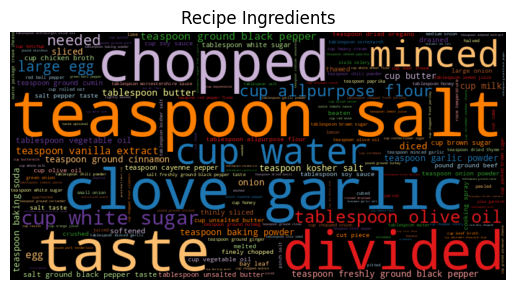

In [39]:
# Word cloud for Ingredients
recipe_tokens_freq = count_words(recipes_df, column='Ingre_Tokens')
wordcloud(recipe_tokens_freq['freq'], title = "Recipe Ingredients")

In [56]:
# Creating custom list of stopwords that can add noise to the data
sw_list = ["cup", "teaspoon", "tablespoon", "ounce", "pound", "ground", "salt", "taste"]

def remove_custom_stopwords_ingre(tokens) :
    cleaned_tokens = []
    for token in tokens:
        words = token.split()
        filtered_words = [word for word in words if word not in sw_list]
        cleaned_tokens.append(" ".join(filtered_words))
    print(cleaned_tokens)
    return cleaned_tokens

In [57]:
recipes_df['Ingre_Tokens'] = recipes_df['Ingre_Tokens'].apply(remove_custom_stopwords_ingre)

['refried bean', 'guacamole', 'sour cream', 'packet taco seasoning', 'shredded cheddar cheese', 'pre shredded lettuce', 'rom tomato', 'seeded finely chopped', 'finely chopped white onion', 'jalapeno', 'seeded optional chopped', 'shredded pepper jack cheese', 'sliced black olive', 'finely chopped cilantro', 'pickled jalapeno slice']
['beef', 'package taco seasoning']
['frozen chicken wing', 'thawed', 'fluid barbeque sauce original', 'mapleflavored syrup mr']
['mashed banana', 'rolled oat', 'raisin']
['peach light syrup', 'package yellow cake mix', 'butter', 'melted']
['mango puree mango', 'heavy cream', 'white sugar']
['small ripe spotted banana', 'divided', 'large egg', 'room temperature', 'plus packed dark brown sugar', 'divided', 'self rising flour']
['skinless', 'boneless chicken breast half', 'condensed cream chicken soup', 'mixed vegetable', 'drained', 'package doublecrust pie pastry', 'thawed']
['pasta', 'beef', '', 'freshly black pepper', 'garlic powder', '', 'tomato soup', 'can

### After removing custom stopwords

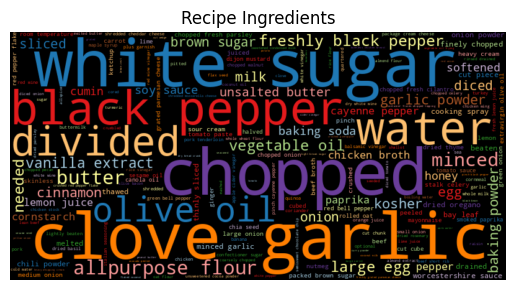

In [50]:
# Word cloud for Ingredients
recipe_tokens_freq = count_words(recipes_df, column='Ingre_Tokens')
wordcloud(recipe_tokens_freq['freq'], title = "Recipe Ingredients")

### Using nouns only

In [58]:
# Function to include nouns only

def include_nouns(tokens) :
    all_nouns = []
    for token in tokens:
        words = token.split()
        filtered_words = [word for word, pos in pos_tag(words) if pos.startswith('N')]
        if filtered_words:
            all_nouns.append(" ".join(filtered_words))
    print(all_nouns)
    return all_nouns

In [59]:
recipes_df['Ingre_Tokens'] = recipes_df['Ingre_Tokens'].apply(include_nouns)

['bean', 'guacamole', 'cream', 'packet taco', 'cheddar cheese', 'pre lettuce', 'rom tomato', 'onion', 'jalapeno', 'chopped', 'pepper jack cheese', 'olive', 'cilantro', 'jalapeno slice']
['beef', 'package taco']
['chicken wing', 'thawed', 'fluid barbeque', 'syrup mr']
['banana', 'oat', 'raisin']
['peach light syrup', 'package cake mix', 'butter']
['mango mango', 'cream', 'sugar']
['ripe banana', 'egg', 'room temperature', 'brown sugar', 'self flour']
['skinless', 'boneless breast half', 'cream chicken soup', 'vegetable', 'package doublecrust pie pastry', 'thawed']
['pasta', 'beef', 'pepper', 'powder', 'tomato soup', 'homemade', 'mozzarella cheese']
['frozen peach', 'thawed', 'sugar', 'cooking spray', 'package cake mix', 'butter', 'cut piece']
['beef tenderloin steak', 'potato', 'juice cocktail', 'carrot', 'celery', 'onion', 'tapioca', 'sugar', 'pepper']
['bow tie pasta', 'oil', 'package sausage', 'cut thick slice', 'blend cajun style mirepoix blend', 'cajun', 'cream', 'cheese']
['milk',

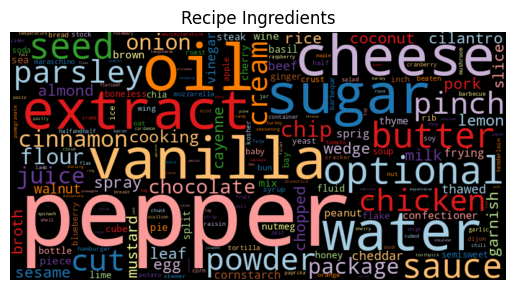

In [32]:
# Word cloud for Ingredients (Only nouns)
recipe_tokens_freq = count_words(recipes_df, column='Ingre_Tokens')
wordcloud(recipe_tokens_freq['freq'], title = "Recipe Ingredients")

In [60]:
recipes_df['Ingre_Tokens']

0       [bean, guacamole, cream, packet taco, cheddar ...
1                                    [beef, package taco]
2        [chicken wing, thawed, fluid barbeque, syrup mr]
3                                   [banana, oat, raisin]
4           [peach light syrup, package cake mix, butter]
                              ...                        
3330    [flour, powder, soda, sugar, oil, egg, vanilla...
3331    [zucchini, lengthwise plank, oil, kosher, milk...
3332    [flour, wheat flour, oat flour, soda, powder, ...
3333    [pearl barley, oil, pancetta bacon, onion, cho...
3334    [flour, powder, sugar, vanilla sugar, pinch, b...
Name: Ingre_Tokens, Length: 3335, dtype: object

In [76]:
import nltk
vocabulary = nltk.FreqDist()

def calculate_ingredient_frequency(rows):
    for tokens in rows:
        for token in tokens:
            words = token.split()
            vocabulary.update(words)
    return vocabulary.most_common(200)

In [78]:
top_ingredients = calculate_ingredient_frequency(recipes_df['Ingre_Tokens'])

for word, frequency in top_ingredients:
    print(f'{word};{frequency}')

pepper;2173
oil;1487
onion;1379
sugar;1349
powder;1083
flour;1030
butter;1014
sauce;908
water;883
garlic;875
egg;778
chopped;705
chicken;699
cheese;619
beef;576
package;531
milk;522
juice;520
tomato;505
cut;500
cream;441
vanilla;426
extract;402
rice;391
broth;377
lemon;371
vinegar;369
brown;365
cinnamon;342
seed;324
kosher;313
leaf;309
pork;308
piece;297
pinch;296
soy;288
medium;284
almond;281
carrot;278
parsley;273
bell;270
wine;269
boneless;245
mushroom;244
soda;238
ginger;235
paprika;226
celery;225
thyme;223
slice;222
cayenne;222
cumin;214
apple;214
coconut;211
honey;207
mustard;206
mix;205
chili;202
potato;201
oregano;194
oat;193
lime;190
cooking;188
cube;184
cilantro;182
bean;177
bread;177
paste;172
orange;164
skinless;158
spray;158
worcestershire;157
rib;156
breast;154
cornstarch;150
clove;150
corn;150
peanut;149
chocolate;148
optional;148
fluid;147
sesame;141
banana;138
crumb;137
chile;136
chip;135
roast;135
basil;134
thawed;132
bay;131
steak;128
cherry;126
chunk;126
flake;125
c

In [34]:
from collections import Counter

ingredients = [token for sublist in recipes_df['Ingre_Tokens'] for token in sublist]
ingredient_counts = Counter(ingredients)

# Get the top 30 ingredients
top_30_ingredients = [ingredient for ingredient, count in ingredient_counts.most_common(30)]
top_30_ingredients

['pepper',
 'oil',
 'vanilla',
 'sugar',
 'cheese',
 'extract',
 'water',
 'optional',
 'seed',
 'butter',
 'sauce',
 'parsley',
 'powder',
 'cut',
 'pinch',
 'chicken',
 'cream',
 'cinnamon',
 'package',
 'juice',
 'flour',
 'onion',
 'chip',
 'cooking',
 'chocolate',
 'spray',
 'garnish',
 'chopped',
 'cilantro',
 'milk']